In [60]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
import math
from sklearn.preprocessing import StandardScaler, normalize

In [49]:
data = pd.read_csv("./datasets/final.csv")
data

,nvmops,objective,eval_duration_solver,extract_duration_solver,stats_elapsed_time,name,dual_feas,status,timed_bytes,timed_time,...,jtprod_residual_available,alloc_grad,inequality_constrained,time_hess,lin_nnzj,nnzh,timestamp_problem,adbackend_hprod_backend_type,error_type,total_alloc
0,34.0,8.624897e-10,0.392040,0.100762,0.089514,dqdrtic,0.000109,first_order,124640.0,0.089571,...,NaN,2.789270e+08,False,NaN,0.0,5.005000e+05,2026-01-31 17:27:24.381,ADNLPModels.ForwardDiffADHvprod{ForwardDiff.Ta...,NaN,723.910448
1,12.0,1.763693e-09,0.392040,0.048325,0.037171,dqdrtic,0.000478,first_order,148496.0,0.037217,...,NaN,2.789270e+08,False,NaN,0.0,5.005000e+05,2026-01-31 17:27:24.381,ADNLPModels.ForwardDiffADHvprod{ForwardDiff.Ta...,NaN,723.910448
2,15.0,4.667330e-12,0.392040,0.054916,0.043753,dqdrtic,0.000050,first_order,181760.0,0.043809,...,NaN,2.789270e+08,False,NaN,0.0,5.005000e+05,2026-01-31 17:27:24.381,ADNLPModels.ForwardDiffADHvprod{ForwardDiff.Ta...,NaN,723.910448
3,11.0,1.352652e-10,0.392040,0.044040,0.032844,dqdrtic,0.000229,first_order,212448.0,0.032927,...,NaN,2.789270e+08,False,NaN,0.0,5.005000e+05,2026-01-31 17:27:24.381,ADNLPModels.ForwardDiffADHvprod{ForwardDiff.Ta...,NaN,723.910448
4,12.0,1.724090e-10,0.392040,0.047996,0.036781,dqdrtic,0.000281,first_order,244912.0,0.036879,...,NaN,2.789270e+08,False,NaN,0.0,5.005000e+05,2026-01-31 17:27:24.381,ADNLPModels.ForwardDiffADHvprod{ForwardDiff.Ta...,NaN,723.910448
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21482,40.0,1.855425e-10,0.068329,895.371150,895.103355,srosenbr,0.000608,first_order,314445176.0,895.370630,...,NaN,3.261877e+10,False,NaN,0.0,5.000050e+09,2026-01-28 16:05:44.303,ADNLPModels.ForwardDiffADHvprod{ForwardDiff.Ta...,NaN,32716.807320
21483,40.0,1.855425e-10,0.068329,834.451648,834.184401,srosenbr,0.000608,first_order,317641296.0,834.451126,...,NaN,3.261877e+10,False,NaN,0.0,5.000050e+09,2026-01-28 16:05:44.303,ADNLPModels.ForwardDiffADHvprod{ForwardDiff.Ta...,NaN,32716.807320
21484,40.0,1.855425e-10,0.068329,866.002412,865.728673,srosenbr,0.000608,first_order,320841440.0,866.001898,...,NaN,3.261877e+10,False,NaN,0.0,5.000050e+09,2026-01-28 16:05:44.303,ADNLPModels.ForwardDiffADHvprod{ForwardDiff.Ta...,NaN,32716.807320
21485,40.0,1.855425e-10,0.068329,835.319132,835.027454,srosenbr,0.000608,first_order,324041584.0,835.318577,...,NaN,3.261877e+10,False,NaN,0.0,5.000050e+09,2026-01-28 16:05:44.303,ADNLPModels.ForwardDiffADHvprod{ForwardDiff.Ta...,NaN,32716.807320


### Explore relationship with data via Gaussian Mixture Models

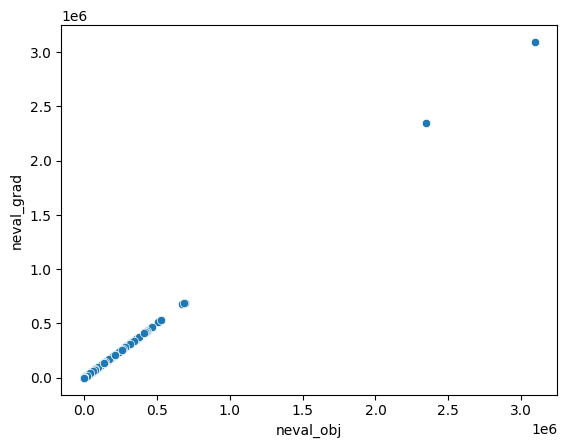

In [18]:
sns.scatterplot(data=data, x="neval_obj", y="neval_grad")
plt.show()

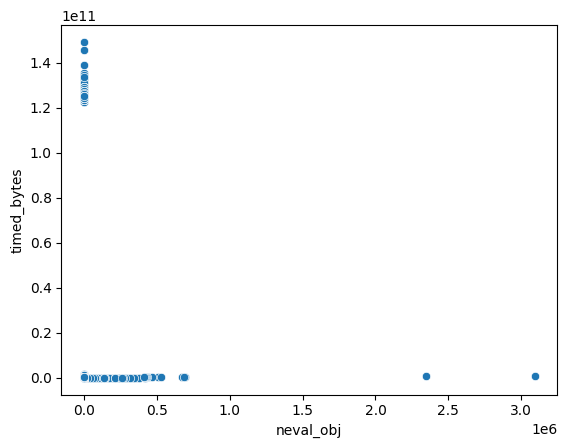

In [19]:
sns.scatterplot(data=data, x="neval_obj", y="timed_bytes")
plt.show()

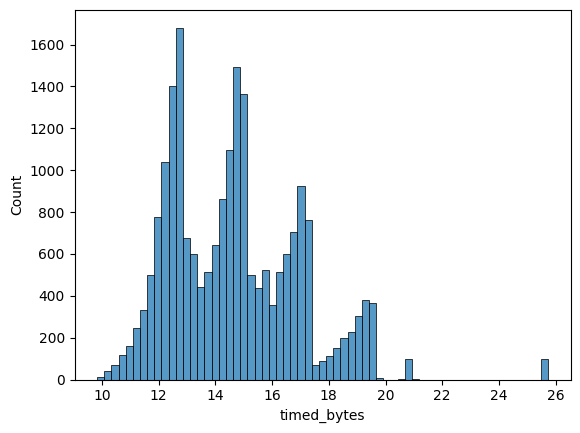

In [35]:
x = data["timed_bytes"]
x.describe()
y = data["nvar"]

sns.histplot(x=np.log1p(x))
plt.show()

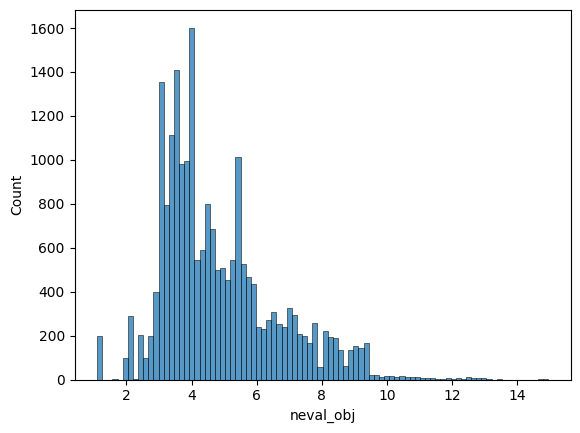

In [21]:
x = data["neval_obj"]
x.describe()

sns.histplot(x=np.log1p(x))
plt.show()

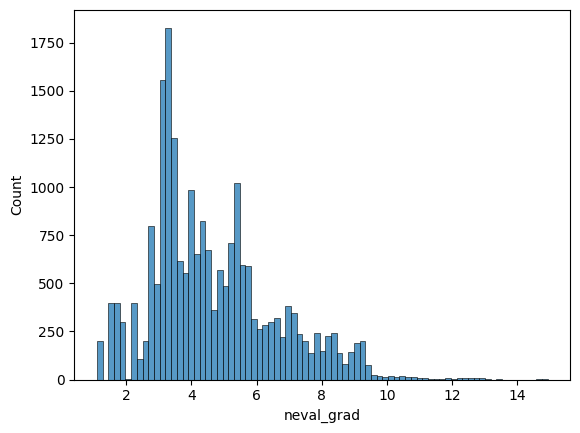

In [22]:
x = data["neval_grad"]
x.describe()

sns.histplot(x=np.log1p(x))
plt.show()

### Training a Gaussian Mixture Model to model the trimodal distribution log1p(data["timed_bytes"]) illustrates above

In [64]:
feature_cols_reg = [
                    # Core Features
                    "nvar", 
                    "tree_length", 
                    "tree_depth", 
                    "time_obj",  # initial eval
                    "time_grad",
                    "mem",
                    "extract_duration_problem",
                    "eval_duration_problem",
                    
                    # Expression Tree Features
                    "highest_degree (ExprTree)",
                    "count_plus_minus",
                    "count_trigonometric_function",
                    "count_exponential_function",
                    "count_op_function",

                    # allocation
                    "alloc_obj",
                    "alloc_grad",
                    "alloc_hess",
                    "alloc_hprod",
                    "total_alloc",
                  ]

target_cols_reg = [ "neval_obj",
                    "neval_grad",
                    "timed_bytes"] #(neval_obj, neval_grad, timed_bytes)

target_col_model = ["stats_elapsed_time"]

In [1]:
gmm = GaussianMixture(n_components = 3) 
gmm.fit(data["timed_bytes"].dropna(axis=1))

NameError: name 'GaussianMixture' is not defined

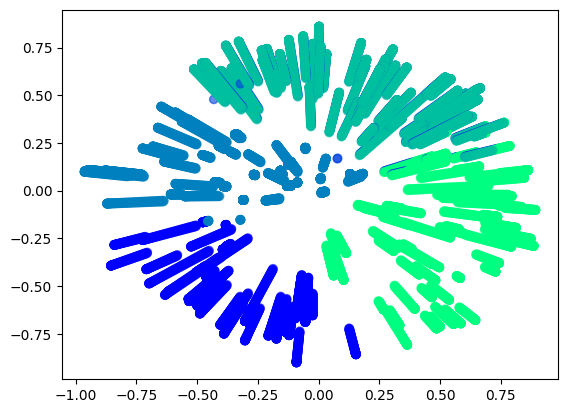

In [79]:
plt.scatter(X_principal['P1'], X_principal['P2'],  
           c = GaussianMixture(n_components = 5).fit_predict(X_principal), cmap =plt.cm.winter, alpha = 0.6) 
plt.show() 

In [ ]:
X = data["timed_bytes"].to_numpy().reshape(-1, 1)
length = len(X)
X_train = X[:math.floor(0.8 * length)]
X_test = X[math.floor(0.8 * length):]
gm = GaussianMixture(n_components=3, random_state=0).fit(X_train)
labels = gm.predict(X_test)
labels


IndexError: index 1 is out of bounds for axis 1 with size 1